# Task 2


### Import data

In [ ]:
!pip install hazm "numpy>=1.26.0" --upgrade --force-reinstall

In [2]:
import json
import pandas as pd

with open('/content/PerCQA_JSON_Format.json', 'r', encoding='utf-8-sig') as f:
    data = json.load(f)

df = pd.json_normalize(data,
                       record_path='Comments',
                       meta=[
                           'QID', 'QDATE', 'QUSERID', 'QTYPE', 'QGOLD_YN',
                           'QUsername', 'QBody', 'QSubject'
                       ],
                       errors='ignore')

df.head()


,CID,CUSERID,CGOLD,CGOLD_YN,CSubject,CBody,CBodyClean,CUsername,CDate,LabelDate,ReplayCommentId,QID,QDATE,QUSERID,QTYPE,QGOLD_YN,QUsername,QBody,QSubject
0,50758322,4918,Good,,,قهر جدا تولد جدا. ضمنا خواهرانه میگم این قهر و...,قهر جدا تولد جدا. ضمنا خواهرانه میگم این قهر و...,mahboub,None,2020-04-28T23:57:28.9458377,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
1,50758362,4939,Good,,,انقدر تحويلش نگير تا خودش بياد سمتت،اين جوري ا...,انقدر تحویلش نگیر تا خودش بیاد سمتت ، این جوری...,eshghiii,None,2020-04-29T00:32:46.1344058,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
2,50758382,9102,Good,,,تولد براش بگير. قهر جداس,تولد براش بگیر. قهر جداس,44,None,2020-04-29T00:32:48.054768,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
3,50758410,9103,Good,,,تولدشون رو تبریک بگین . جوری که احساس نکنن دار...,تولدشون رو تبریک بگین. جوری که احساس نکنن داری...,golsa82,None,2020-04-29T00:43:34.305984,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
4,50758416,8643,Good,,,تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...,تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...,بهاران_عشق,None,2020-04-29T00:43:41.4450752,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم


In [3]:
import pandas as pd

df_QID = pd.read_json("/content/PerCQA_JSON_Format.json", encoding='utf-8-sig')
df_QID.head()


,QID,QCATEGORY,QDATE,QUSERID,QTYPE,QGOLD_YN,QUsername,QBody,QSubject,Comments
0,1550088,NaN,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم,"[{'CID': '50758322', 'CUSERID': 4918, 'CGOLD':..."
1,1558609,NaN,2018-01-06T00:17:00,6856,General,Not Applicable,khanoomi72,من خودم حس میکنم اشتباهم گیر دادن بیخودی و غر ...,بزرگترین اشتباه دوران نامزدیتون چی بوده؟؟,"[{'CID': '51114707', 'CUSERID': 3935, 'CGOLD':..."
2,1587820,NaN,2018-01-22T13:23:00,9918,General,Not Applicable,lol,سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه....,کمک سالگرد ازدواجم نزدیکه,"[{'CID': '52336355', 'CUSERID': 10255, 'CGOLD'..."
3,4414921,NaN,2020-05-23T02:06:00,81403,General,Not Applicable,sepide1400,دختر من چهارده ماهه است. آیا برای تشخیص پرانتز...,متخصص ارتوپدی برای درمان پرانتزی پا,"[{'CID': '138006316', 'CUSERID': 38437, 'CGOLD..."
4,3109668,NaN,2019-08-13T12:07:00,25700,General,Not Applicable,نسا۷۹,چه پمادی بزنم و از چیه اینجور شده . واضح نیس...,لپ پسرم قرمز دون دونه,"[{'CID': '100859930', 'CUSERID': 33391, 'CGOLD..."


In [4]:
!pip install parsivar
!pip install arabic_reshaper


In [5]:
!pip install python-bidi

### Preprocess

In [6]:
from hazm import WordTokenizer
from hazm.utils import stopwords_list
from hazm import Lemmatizer
from hazm import Normalizer as HazmNormalizer
from parsivar import Normalizer as ParsivarNormalizer
import re
import arabic_reshaper
from bidi.algorithm import get_display
import string

normalizer_hazm = HazmNormalizer()
normalizer_parsivar = ParsivarNormalizer()
tokenizer = WordTokenizer()
stemmer = Lemmatizer()
stopwords = set(stopwords_list())


def reshape_tokens(token_list):
    return [get_display(arabic_reshaper.reshape(token)) for token in token_list]


def remove_stopwords(token_list):

    return [token for token in token_list if token.strip() not in stopwords]


def stem_tokens(token_list):
    return [stemmer.lemmatize(token) for token in token_list]


def clean_text(text):
    text = re.sub(r'&[^\s;]+;?', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[.]{2,}', '...', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[' + string.punctuation + '«»؟،؛]', ' ', text)
    return text.strip()


def clean_spaces(text):
    text = re.sub(r'[\u200b\u200c\ufeff]', ' ', text)
    return text


def clean_and_tokenize_column(df, column_name):

    result = df[column_name].apply(clean_text)
    result = result.apply(normalizer_hazm.normalize)
    result = result.apply(normalizer_parsivar.normalize)
    result = result.apply(clean_spaces)
    result = result.apply(tokenizer.tokenize)
    result = result.apply(stem_tokens)
    result = result.apply(remove_stopwords)
    return result


def clean_and_tokenize_column_with_stopwords(df, column_name):

    result = df[column_name].apply(clean_text)
    result = result.apply(normalizer_hazm.normalize)
    result = result.apply(normalizer_parsivar.normalize)
    result = result.apply(clean_spaces)
    result = result.apply(tokenizer.tokenize)
    result = result.apply(lambda x: x.strip())
    result = result.apply(stem_tokens)
    return result


df['clean_CBody'] = clean_and_tokenize_column(df, 'CBody')
df_QID['clean_QBody'] = clean_and_tokenize_column(df_QID, 'QBody')
df_QID['clean_QBody_with_stopwords'] = clean_and_tokenize_column(df_QID, 'QBody')
df['clean_CBody_with_stopwords'] = clean_and_tokenize_column(df, 'CBody')


In [7]:
for qid in df["QID"].unique()[:4]:
    question_data = df[df["QID"] == qid]

    question = question_data.iloc[0]
    print("Q:", question["QSubject"])
    print("Body:", question["QBody"])

    for i in range(5):
        print("Answers:", question_data["CBody"].tolist()[i])
        print("Clean Answer", question_data["clean_CBody"].tolist()[i])

    print("=" * 50)

Q: قهر شوهرم 
Body: دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چه کنم؟موضوع دعوامون چیزی بوده که من مقصرش نیستم...خودشم میدونه ربطی به من نداره
Answers: قهر جدا تولد جدا. ضمنا خواهرانه میگم این قهر و همین ابتدای زندگیت محوش کن عزیزم
Clean Answer ['قهر', 'جدا', 'تولد', 'جدا', 'ضمنا', 'خواهرانه', 'میگ', 'قهر', 'زندگیت', 'محو', 'کن', 'عزیز']
Answers: انقدر تحويلش نگير تا خودش بياد سمتت،اين جوري ادب مي شه كه ديگه قهر نكنه.. البته اگر طاقت مياري كه بهش زنگ نزني اينكاري كه گفتم رو انجام بدي بهترِ عزيزم.
Clean Answer ['انقدر', 'تحویل', 'نگیر', 'بیاد', 'جور', 'ادب', 'شه', 'دیگه', 'قهر', 'نکنه', 'طاقت', 'میاری', 'زنگ', 'زد#زن', 'اینکاری', 'گفت#گو', 'انجام', 'بدی', 'عزیز']
Answers: تولد براش بگير. قهر جداس
Clean Answer ['تولد', 'براش', 'بگیر', 'قهر', 'جداس']
Answers: تولدشون رو تبریک بگین . جوری که احساس نکنن دارین منت کشی میکنین . یعنی نشون بدین دلخورین . برا این میگم تبریک بگین تا بعداا حرف برا گفتن نداشته باشن .
Clean Answer ['تولدشون', 'تبریک', 'بگین', 'جور', 'احساس', 'نکنن', 'دارین', 'منت

In [8]:
def calculate_average_median_word(text_series):
    lengths = text_series.apply(lambda x: len(str(x).split()))
    average_length = lengths.mean()
    median_length = lengths.median()
    return average_length, median_length


def calculate_average_median_char(text_series):
    lengths = text_series.apply(lambda x: len(str(x)))
    average_length = lengths.mean()
    median_length = lengths.median()
    return average_length, median_length


average_word_comment, median_word_comment = calculate_average_median_word(
    df['CBody'])
average_char_comment, median_char_comment = calculate_average_median_char(
    df['CBody'])

average_word_question, median_word_question = calculate_average_median_word(
    df_QID['QBody'])
average_char_question, median_char_question = calculate_average_median_char(
    df_QID['QBody'])

print("Average word count in comments:", average_word_comment)
print("Median word count in comments:", median_word_comment)
print("Average char count in comments:", average_char_comment)
print("Median char count in comments:", median_char_comment)
print("Average word count in questions:", average_word_question)
print("Median word count in questions:", median_word_question)
print("Average char count in questions:", average_char_question)
print("Median char count in questions:", median_char_question)

Average word count in comments: 19.288592740835078
Median word count in comments: 13.0
Average char count in comments: 97.23833348494496
Median char count in comments: 67.0
Average word count in questions: 35.1030303030303
Median word count in questions: 26.0
Average char count in questions: 172.93232323232323
Median char count in questions: 129.0


### Structure of question and answers

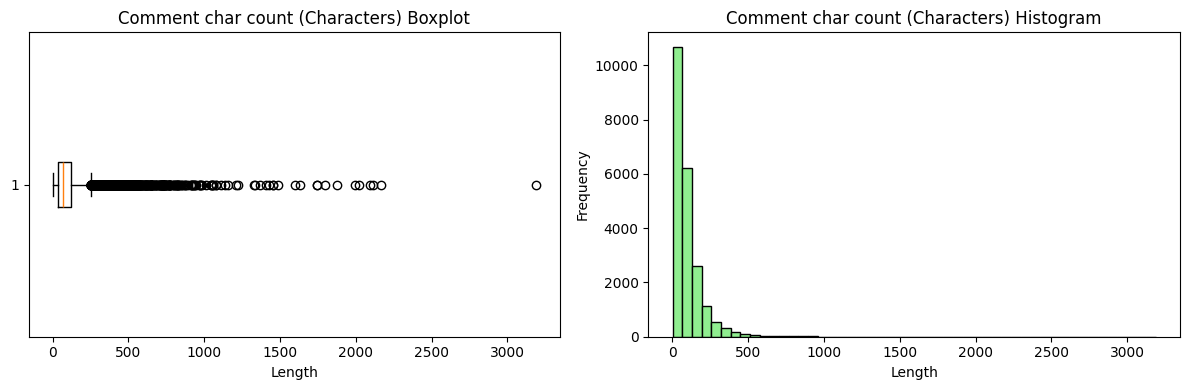

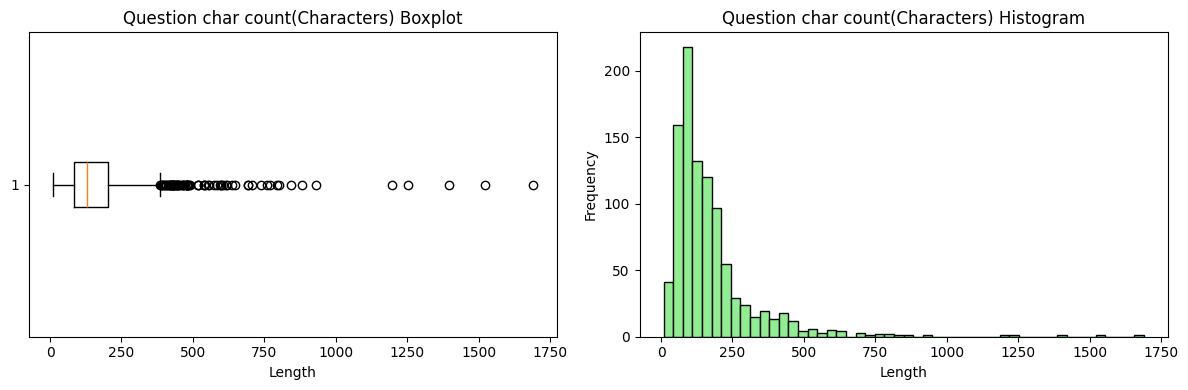

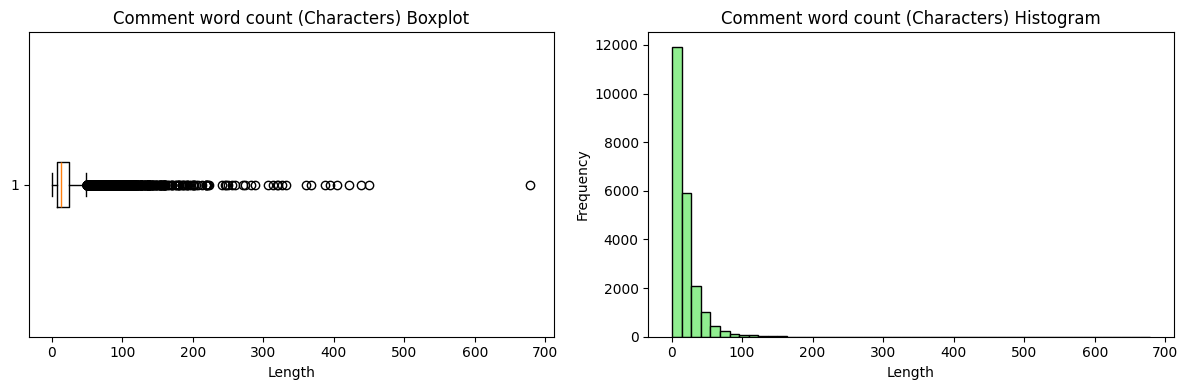

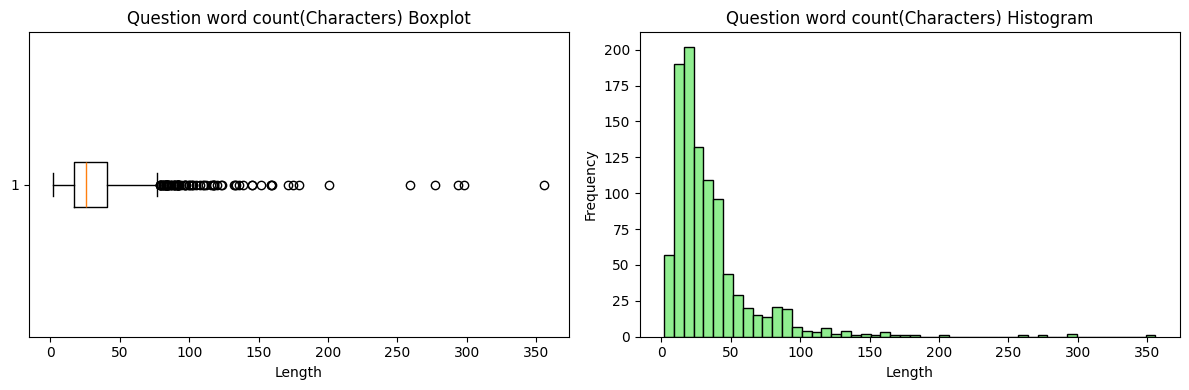

In [9]:
import matplotlib.pyplot as plt

comment_word_counts = df['CBody'].apply(lambda x: len(str(x).split()))
comment_char_counts = df['CBody'].apply(lambda x: len(str(x)))
question_word_counts = df_QID['QBody'].apply(lambda x: len(str(x).split()))
question_char_counts = df_QID['QBody'].apply(lambda x: len(str(x)))


# Histogram for comment lengths
def plot_distribution(lengths, title_prefix=""):
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Boxplot for comment lengths (characters)
    axs[0].boxplot(lengths, vert=False)
    axs[0].set_title(f'{title_prefix} Boxplot')
    axs[0].set_xlabel('Length')

    # Histogram for question lengths (characters)
    axs[1].hist(lengths, bins=50, color='lightgreen', edgecolor='black')
    axs[1].set_title(f'{title_prefix} Histogram')
    axs[1].set_xlabel('Length')
    axs[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


plot_distribution(comment_char_counts, "Comment char count (Characters)")
plot_distribution(question_char_counts, "Question char count(Characters)")

plot_distribution(comment_word_counts, "Comment word count (Characters)")
plot_distribution(question_word_counts, "Question word count(Characters)")


### Identify Engaging Questions

In [10]:
# Group by QID and count number of answers for each question
answer_counts = df.groupby('QID').size().sort_values(ascending=False)

# Get top 10 questions with highest number of answers
top_10_qids = answer_counts.head(10).index

# Display question subject, body, and number of answers
for qid in top_10_qids:
    question_row = df[df['QID'] == qid].iloc[0]
    num_answers = answer_counts[qid]
    print(f"QID: {qid}")
    print(f"Subject: {question_row['QSubject']}")
    print(f"Body: {question_row['QBody']}")
    print(f"Number of answers: {num_answers}")
    print("=" * 50)

QID: 1556257
Subject: با ١٥ ميليون چه چزایی برای جهازتون ميخرين؟ 
Body: با ١٥ تومن چه چيزاي از جهاز و ميشه خريد ؟! كه هم أساسي باشه هم بدرد بخور اگ به عبارات ديگ فقط ١٥-٢٠ تومن برا خريد جهيزيه داشته باشين چه چيزهاي ميخريد و چطور از همسرتون ميخواين كه در خريد كمك كنه؟  جوري كه  هم غرورمن حفظ بشه هم شوهر قانع بشه و بهش برنخوره.  تا حالا هم در اين مورد هيچ حرفي با هم نزديم 
Number of answers: 315
QID: 1577970
Subject: خواندن عقد توسط سید محمد خاتمی
Body: کسی اطلاع داره بخوابم پیش ایشون بريم چطوری و کجا باید هماهنگ کنیم?
Number of answers: 313
QID: 1559359
Subject: کیا طلاق گرفتن...
Body: بعد طلاق چطور خودتونو سرپا نگه داشتین. چطور خودتونو جمع کردین؟  
Number of answers: 215
QID: 1555428
Subject: گواهی سلامت برم بگیرم ؟ 
Body: من یه سال نامزد کردم قرار یه سال دیگه هم نامزد بمونیم عقد کردیم نامزدم و خانوادش اصلا حرفی از نامه سلامت اینا نزدن ولی مامانم همش میگه نه باید بری من چی کنم بدم میاد اخه به نامزدمم گفتم.  گفت خودت میدونی می خوای برو بگیر ولی لزومی نداره (یجوری گفت انگار بی میل هم نبو

### Analyze Activity Pattern

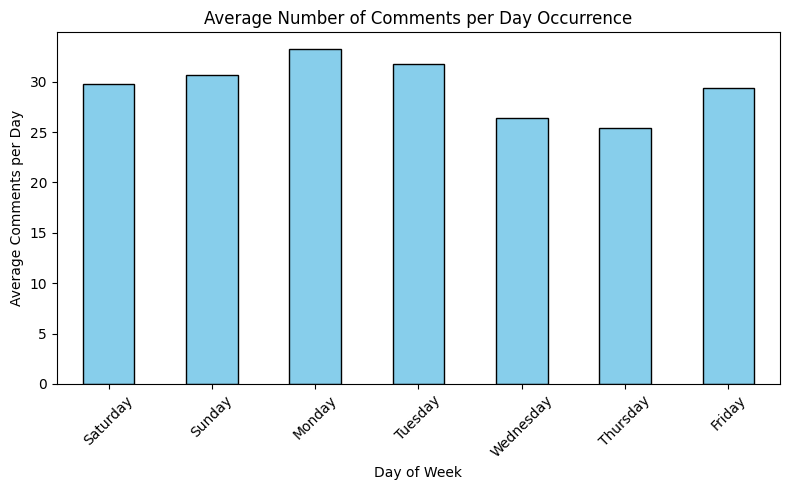

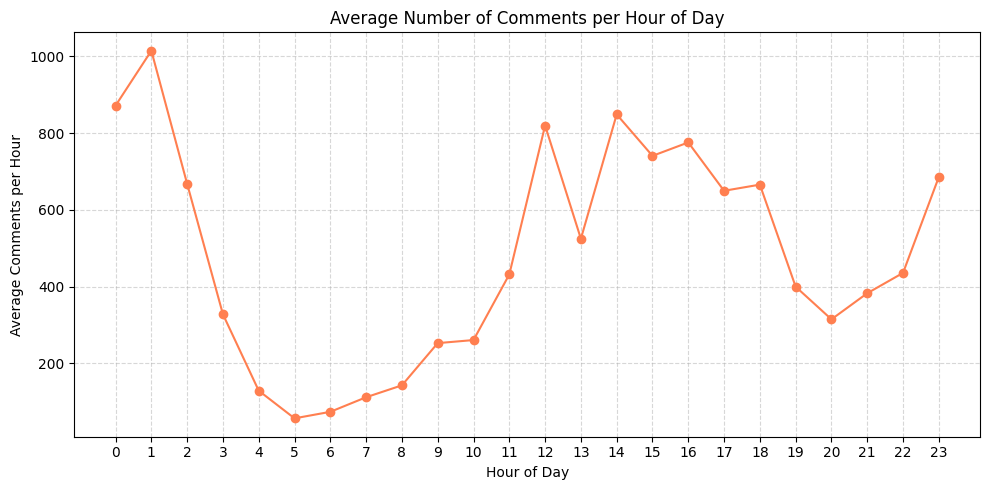

In [11]:
from collections import Counter

df['CDate'] = pd.to_datetime(df['CDate'], errors='coerce')
df['day_of_week'] = df['CDate'].dt.day_name()

day_counts = df['day_of_week'].value_counts().reindex([
    'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'
])

day_occurrences = df['CDate'].dropna().dt.date.groupby(
    df['CDate'].dt.day_name()).nunique().reindex([
        'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday',
        'Friday'
    ])
avg_comments_per_day = day_counts / day_occurrences

plt.figure(figsize=(8, 5))
avg_comments_per_day.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Number of Comments per Day Occurrence')
plt.xlabel('Day of Week')
plt.ylabel('Average Comments per Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['hour_of_day'] = df['CDate'].dt.hour
hour_counts = df['hour_of_day'].value_counts().sort_index()
hour_occurrences = df['CDate'].dropna().dt.hour.groupby(
    df['CDate'].dt.hour).nunique().sort_index()
avg_comments_per_hour = hour_counts / hour_occurrences

plt.figure(figsize=(10, 5))
avg_comments_per_hour.plot(kind='line', marker='o', color='coral')
plt.title('Average Number of Comments per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Comments per Hour')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


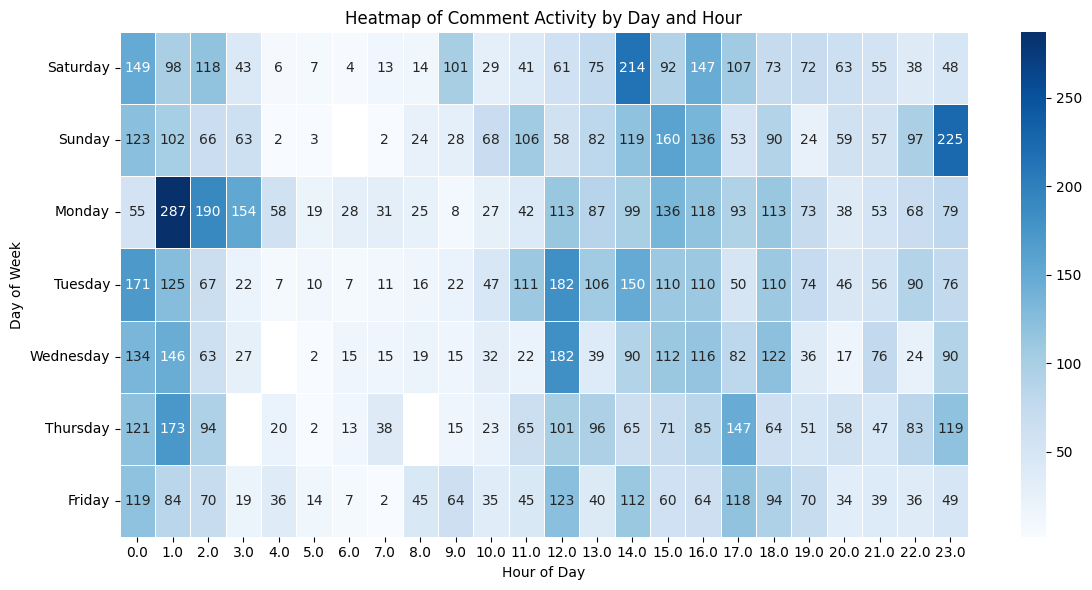

In [12]:
import seaborn as sns

activity_matrix = df.pivot_table(index='day_of_week',
                                 columns='hour_of_day',
                                 values='CBody',
                                 aggfunc='count').reindex([
                                     'Saturday', 'Sunday', 'Monday', 'Tuesday',
                                     'Wednesday', 'Thursday', 'Friday'
                                 ])

plt.figure(figsize=(12, 6))
sns.heatmap(activity_matrix, cmap='Blues', linewidths=0.5, annot=True, fmt='g')
plt.title('Heatmap of Comment Activity by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

### Top Answer Contributors

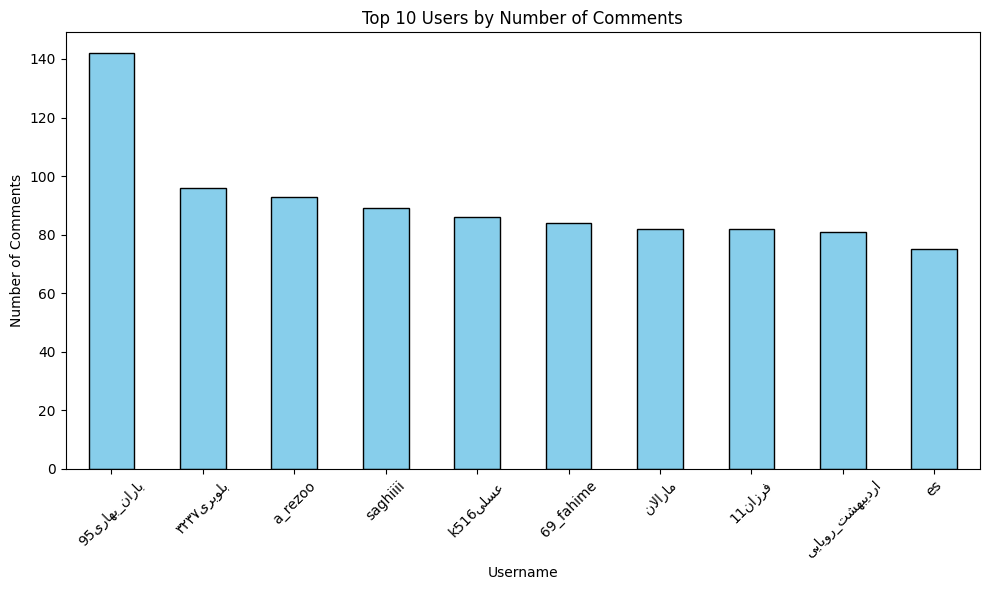

In [13]:
user_comment_counts = df.groupby('CUsername').size().sort_values(
    ascending=False)
top_10_users = user_comment_counts.head(10)

top_10_users.index = [
    get_display(arabic_reshaper.reshape(username))
    for username in top_10_users.index
]
plt.figure(figsize=(10, 6))
top_10_users.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Users by Number of Comments')
plt.xlabel('Username')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Word Level Analysis

/tmp/ipython-input-1495342781.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(question_words, rotation=45)
/tmp/ipython-input-1495342781.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(answer_words, rotation=45)


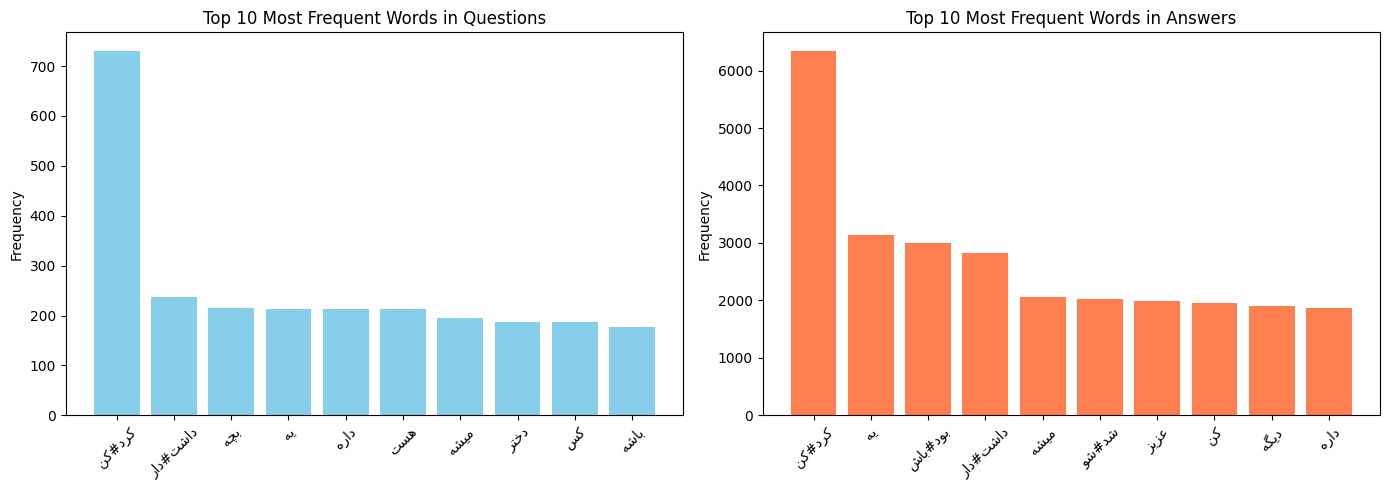

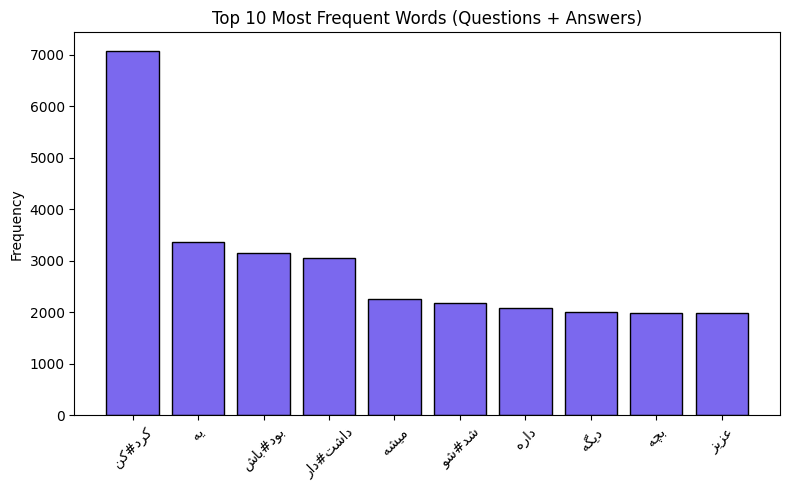

In [14]:
from collections import Counter

all_question_words = [word for words in df_QID['clean_QBody'] for word in words]
all_answer_words = [word for words in df['clean_CBody'] for word in words]

question_word_freq = Counter(all_question_words)
answer_word_freq = Counter(all_answer_words)

top_question_words = question_word_freq.most_common(10)
top_answer_words = answer_word_freq.most_common(10)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

question_words, question_counts = zip(*top_question_words)
question_words = reshape_tokens(question_words)
axs[0].bar(question_words, question_counts, color='skyblue')
axs[0].set_title('Top 10 Most Frequent Words in Questions')
axs[0].set_ylabel('Frequency')
axs[0].set_xticklabels(question_words, rotation=45)

answer_words, answer_counts = zip(*top_answer_words)
answer_words = reshape_tokens(answer_words)
axs[1].bar(answer_words, answer_counts, color='coral')
axs[1].set_title('Top 10 Most Frequent Words in Answers')
axs[1].set_ylabel('Frequency')
axs[1].set_xticklabels(answer_words, rotation=45)

plt.tight_layout()
plt.show()

all_words = all_question_words + all_answer_words
combined_word_freq = Counter(all_words)

top_combined_words = combined_word_freq.most_common(10)
words, counts = zip(*top_combined_words)
words = reshape_tokens(words)
plt.figure(figsize=(8, 5))
plt.bar(words, counts, color='mediumslateblue', edgecolor='black')
plt.title('Top 10 Most Frequent Words (Questions + Answers)')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

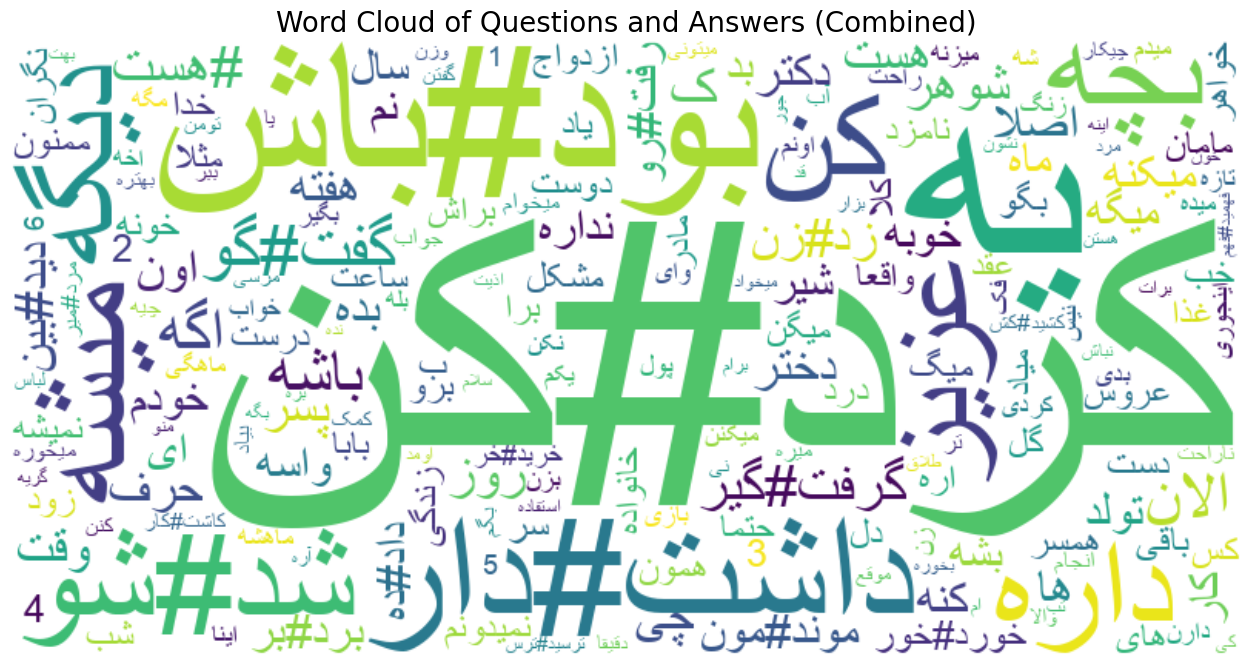

In [15]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

word_freq_dict = dict(combined_word_freq)

wc = WordCloud(width=800,
               height=400,
               background_color='white',
               font_path='arial.ttf').generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Questions and Answers (Combined)', fontsize=20)
plt.show()

/tmp/ipython-input-3099700032.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(bigram_labels, rotation=45, ha='right')
/tmp/ipython-input-3099700032.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(trigram_labels, rotation=45, ha='right')


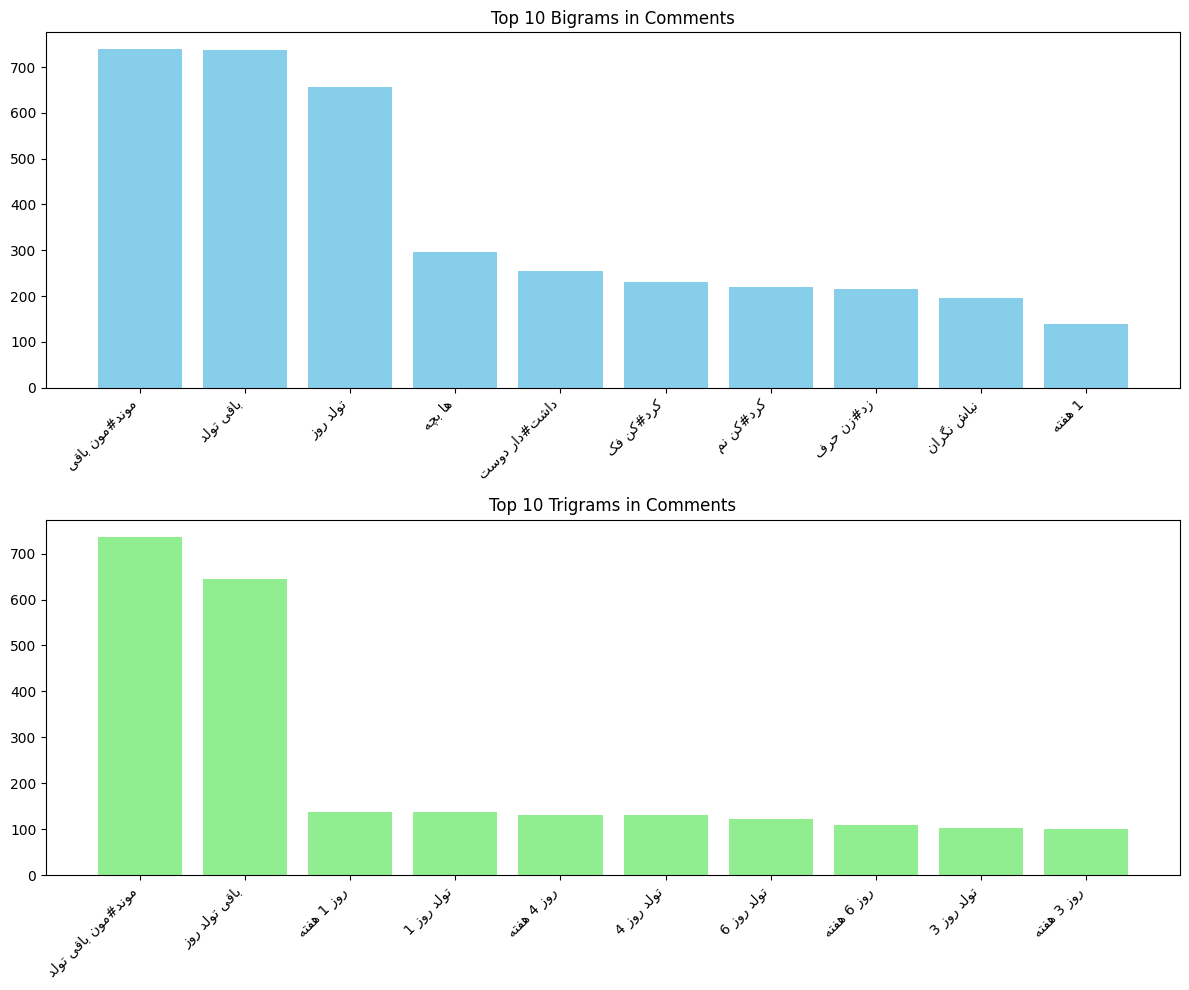

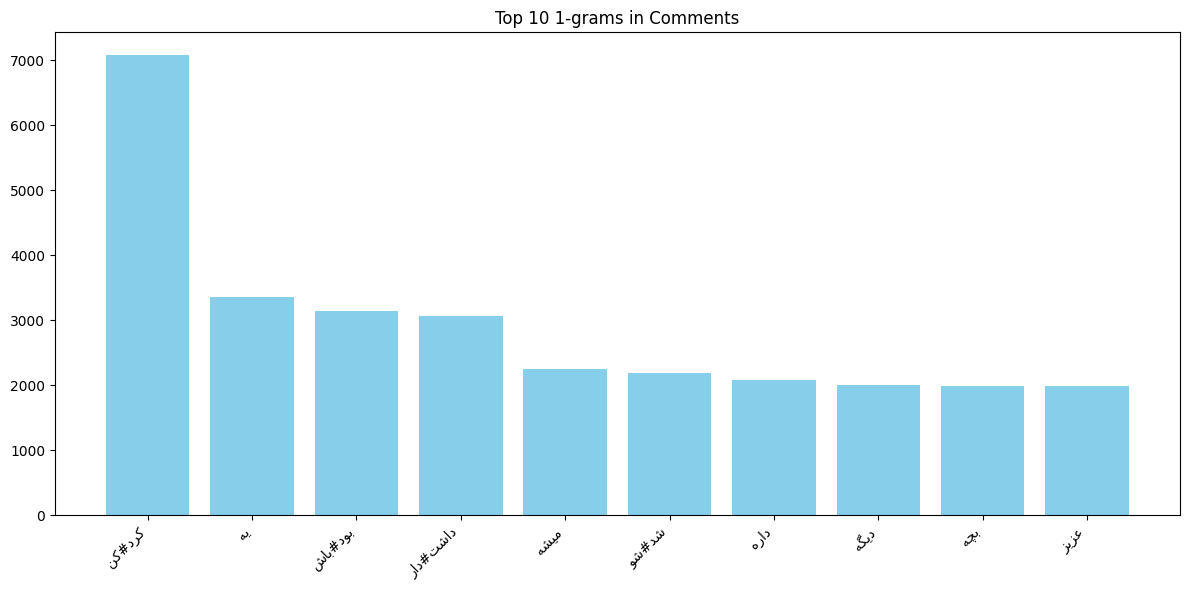

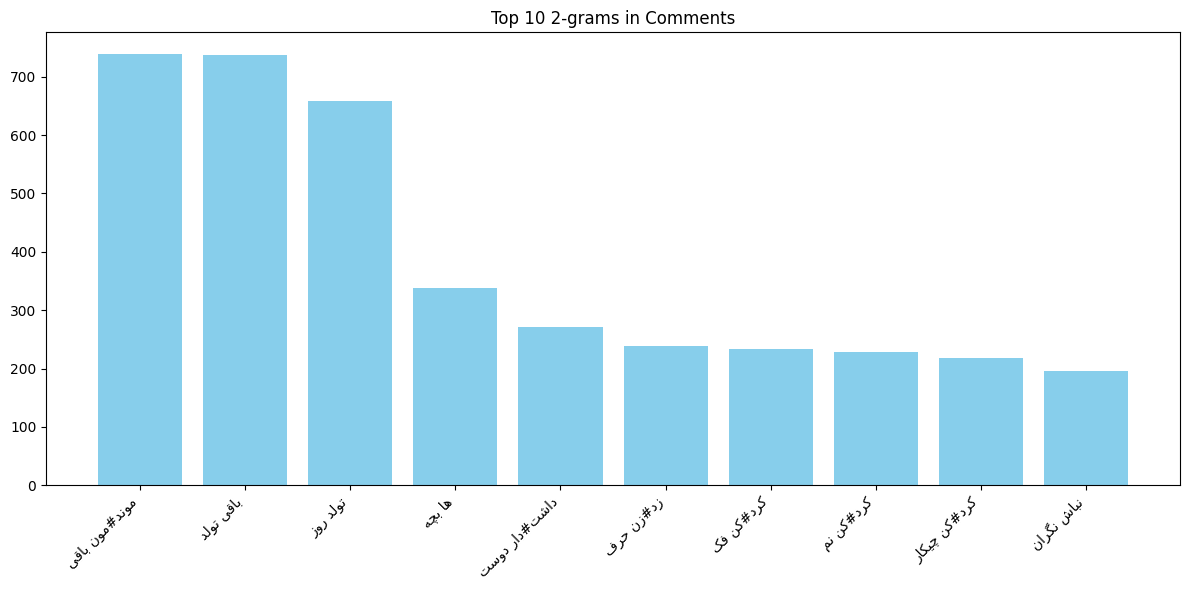

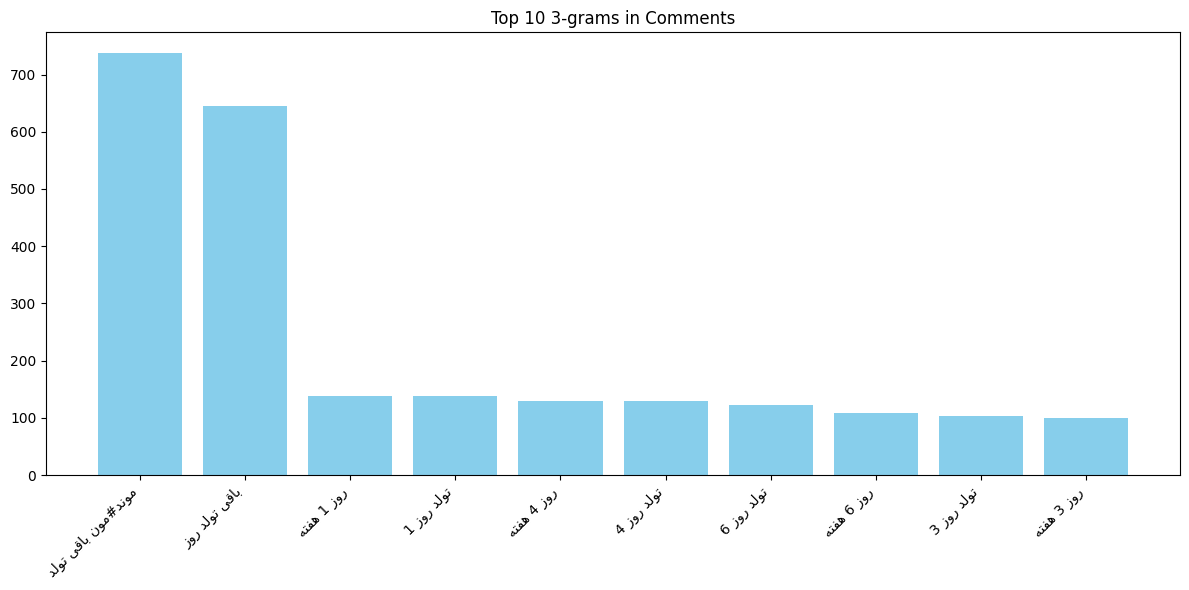

In [16]:
from nltk import ngrams
from collections import Counter

import matplotlib.pyplot as plt


def get_ngrams(tokens_list, n):
    all_ngrams = []
    for tokens in tokens_list:
        ngram_list = list(ngrams(tokens, n))
        all_ngrams.extend(ngram_list)
    return Counter(all_ngrams)


# Get bigrams and trigrams
bigrams = get_ngrams(df['clean_CBody'], 2)
trigrams = get_ngrams(df['clean_CBody'], 3)

# Plot top 10 bigrams and trigrams
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot bigrams
top_bigrams = dict(bigrams.most_common(10))
bigram_labels = [
    ' '.join(get_display(arabic_reshaper.reshape(word))
             for word in bg)
    for bg in top_bigrams.keys()
]
ax1.bar(bigram_labels, top_bigrams.values(), color='skyblue')
ax1.set_title('Top 10 Bigrams in Comments')
ax1.set_xticklabels(bigram_labels, rotation=45, ha='right')

# Plot trigrams
top_trigrams = dict(trigrams.most_common(10))
trigram_labels = [
    ' '.join(get_display(arabic_reshaper.reshape(word))
             for word in tg)
    for tg in top_trigrams.keys()
]
ax2.bar(trigram_labels, top_trigrams.values(), color='lightgreen')
ax2.set_title('Top 10 Trigrams in Comments')
ax2.set_xticklabels(trigram_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

from nltk import ngrams
from collections import Counter

import matplotlib.pyplot as plt

def plot_ngrams(tokens_list, n):
  # Get n-grams
  ngrams_counter = Counter()
  for tokens in tokens_list:
    ngram_list = list(ngrams(tokens, n))
    ngrams_counter.update(ngram_list)

  # Plot top 10 n-grams
  plt.figure(figsize=(12, 6))

  # Get top n-grams
  top_ngrams = dict(ngrams_counter.most_common(10))
  ngram_labels = [
    ' '.join(get_display(arabic_reshaper.reshape(word))
        for word in ng)
    for ng in top_ngrams.keys()
  ]

  plt.bar(ngram_labels, top_ngrams.values(), color='skyblue')
  plt.title(f'Top 10 {n}-grams in Comments')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()
combined_tokens = df_QID['clean_QBody'].tolist() + df['clean_CBody'].tolist()
plot_ngrams(combined_tokens,1)
plot_ngrams(combined_tokens,2)
plot_ngrams(combined_tokens,3)

## Analyze The Dataset

### BGE model

In [17]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")
model = AutoModel.from_pretrained("BAAI/bge-m3")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

In [18]:
import torch

random_qbody = df_QID['QBody'].sample(1).iloc[0]

inputs = tokenizer(random_qbody,
                   return_tensors="pt",
                   truncation=True,
                   max_length=512)
with torch.no_grad():
    outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

print("Random QBody:", random_qbody)
print("Embedding shape:", embedding.shape)
print("Embedding:", embedding)

Random QBody: سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه. عقدم هستیم . کادو براش تا الان عطر و زنجیر و گردنبند طلا و ست چرم برای تولدو مناسبتهای قبل خریدم. البته هر سری باکس گلم دادم. چی بخرم به نظرتون؟ . لباسی دوست ندارم یه چیز خاص میخوام البته امسال پول ندارم و در حد ۳۰۰یا حداکثر ۴۰۰ بتونم خرید کنم
Embedding shape: (1024,)
Embedding: [-0.39736968  0.80560225 -0.46232513 ... -0.2067296  -0.10181811
 -0.48383027]


### Install Lancedb

In [19]:
!pip install lancedb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.6/229.6 kB 18.6 MB/s eta 0:00:00


### Defining shcema and text embedding function

In [20]:
from lancedb.embeddings import register, TextEmbeddingFunction
import torch
from cachetools import cached
import pyarrow as pa
from tqdm import tqdm

@register("bge-m3")
class BgeM3EmbeddingFunction(TextEmbeddingFunction):
    name: str = "BAAI/bge-m3"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    _ndims = None

    def generate_embeddings(self, texts, batch_size=16):
        if isinstance(texts, str):
            texts = [texts]
        tokenizer, model = self._embedding_model()
        device = self.device
        all_embeddings = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
            batch = texts[i:i + batch_size]

            inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)
            inputs = {key: value.to(device) for key, value in inputs.items()}

            with torch.no_grad():
                outputs = model(**inputs)
                embeddings = outputs.last_hidden_state.mean(dim=1)

            all_embeddings.extend(embeddings.cpu().numpy().tolist())

        return all_embeddings

    def ndims(self):
        if self._ndims is None:
            self._ndims = 1024
        return self._ndims

    @cached(cache={})
    def _embedding_model(self):
        from transformers import AutoTokenizer, AutoModel
        tokenizer = AutoTokenizer.from_pretrained(self.name)
        model = AutoModel.from_pretrained(self.name).to(self.device)
        return tokenizer, model

embedder = BgeM3EmbeddingFunction.create()


In [21]:
from lancedb.pydantic import LanceModel, Vector

class MySchema(LanceModel):
    qid: int
    qbody: str = embedder.SourceField()
    vector: Vector(embedder.ndims()) = embedder.VectorField()

In [22]:
import lancedb
db = lancedb.connect("./NiniSite.db")
table = db.create_table("NiNiSiteTable", schema=MySchema)


### Populate Database

In [23]:
data = []
for _, row in df_QID.iterrows():
    data.append({'qid': int(row['QID']), 'qbody': str(row['QBody'])})

table.add(data)

print(f"Added {len(data)} questions to the database")

Generating embeddings: 100%|██████████| 62/62 [00:27<00:00,  2.23it/s]


Added 990 questions to the database


### Semantic Search

In [24]:
def semantic_search(query, top_k=5):
    query_embedding = embedder.generate_embeddings(query)
    results = table.search(query_embedding).limit(top_k).to_pandas()
    return results


In [25]:

for i in range(5):
    sample_query = df_QID["QBody"].iloc[i]
    results = semantic_search(sample_query)
    print(f"Query: {sample_query}\n")
    print(f"Top {5} similar questions:")
    for i, row in results.iterrows():
        print(f"\nRank {i+1}:")
        print(f"Question: {row['qbody']}")
        print(f"Similarity Score: {row['_distance']}")
        print("-" * 80)
    print("="*50)


Generating embeddings: 100%|██████████| 1/1 [00:00<00:00,  6.14it/s]


Query: دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چه کنم؟موضوع دعوامون چیزی بوده که من مقصرش نیستم...خودشم میدونه ربطی به من نداره

Top 5 similar questions:

Rank 1:
Question: دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چه کنم؟موضوع دعوامون چیزی بوده که من مقصرش نیستم...خودشم میدونه ربطی به من نداره
Similarity Score: 38.931007385253906
--------------------------------------------------------------------------------

Rank 2:
Question: من اوایل نامزدیم از رو بی تجربگی ی اشتباهی کردم . برا نامزدم تولد گرفته بودم سر یک موضوعی سوتفاهم پیش اومد برام کلی ناراحت شده بودم درحدی که فقط منتظر بودم اون جشن تموم بشه و من همه چیو تموم کنم  .یکی از فامیلای شوهرم که ما با اونا خیلی رفت و اومد داریم اخرایه جشن که رفتم لباسمو عوض کنم بهم گفت چی شده منم همه چی رو بهش تعریف کردم از بس که بی سیاست بودم الان از اون روز به بعد حس میکنم خیلی داره فضولی میکنه تو زندگیم کلا موذیه. مثلا با تلفن صحبت میکنم گوششو تیز میکنه ببینه من چی گفتم بعدم راجب مکالمم از من سوال میکنه و چیزایی که به اون ربطی نداره از من می

Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 12.10it/s]


Query: من خودم حس میکنم اشتباهم گیر دادن بیخودی و غر زدن های زیادمه. شما چه اشتباهاتی داشتین از نظر خودتون؟. مثلا اگه برمیگشتین عقب انجامش نمیدادین؟

Top 5 similar questions:

Rank 1:
Question: من خودم حس میکنم اشتباهم گیر دادن بیخودی و غر زدن های زیادمه. شما چه اشتباهاتی داشتین از نظر خودتون؟. مثلا اگه برمیگشتین عقب انجامش نمیدادین؟
Similarity Score: 41.88951110839844
--------------------------------------------------------------------------------

Rank 2:
Question: من اوایل نامزدیم از رو بی تجربگی ی اشتباهی کردم . برا نامزدم تولد گرفته بودم سر یک موضوعی سوتفاهم پیش اومد برام کلی ناراحت شده بودم درحدی که فقط منتظر بودم اون جشن تموم بشه و من همه چیو تموم کنم  .یکی از فامیلای شوهرم که ما با اونا خیلی رفت و اومد داریم اخرایه جشن که رفتم لباسمو عوض کنم بهم گفت چی شده منم همه چی رو بهش تعریف کردم از بس که بی سیاست بودم الان از اون روز به بعد حس میکنم خیلی داره فضولی میکنه تو زندگیم کلا موذیه. مثلا با تلفن صحبت میکنم گوششو تیز میکنه ببینه من چی گفتم بعدم راجب مکالمم از من سوال میکنه و چیزای

Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.00it/s]


Query: سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه. عقدم هستیم . کادو براش تا الان عطر و زنجیر و گردنبند طلا و ست چرم برای تولدو مناسبتهای قبل خریدم. البته هر سری باکس گلم دادم. چی بخرم به نظرتون؟ . لباسی دوست ندارم یه چیز خاص میخوام البته امسال پول ندارم و در حد ۳۰۰یا حداکثر ۴۰۰ بتونم خرید کنم

Top 5 similar questions:

Rank 1:
Question: سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه. عقدم هستیم . کادو براش تا الان عطر و زنجیر و گردنبند طلا و ست چرم برای تولدو مناسبتهای قبل خریدم. البته هر سری باکس گلم دادم. چی بخرم به نظرتون؟ . لباسی دوست ندارم یه چیز خاص میخوام البته امسال پول ندارم و در حد ۳۰۰یا حداکثر ۴۰۰ بتونم خرید کنم
Similarity Score: 4.216670068668549e-10
--------------------------------------------------------------------------------

Rank 2:
Question: من اولین سالگرد عقدمه و میخوام همسرم رو سوپرایز کنم میشه کمک کنید که چی بخرم و چکار کنم؟ لطفا کادوهای خاص پیشنهاد بدید. همسرم از مهمونی جمعی خوشش نمیاد زیاد بخاطر همین میخوام یه سوپرایز دو نفره باشه البته تاکید کنم که عقد هستی

Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 19.62it/s]


Query: دختر من چهارده ماهه است. آیا برای تشخیص پرانتزی پاهاش تا دو سالگی اش باید صبر کنم؟ متخصص ارتوپد در تهران چه کسی را پیشنهاد میکنید؟ خیلی نگران دخترم هستم. نمیخوام مثل من از پرانتزی پاش خجالت بکشه.

Top 5 similar questions:

Rank 1:
Question: دختر من چهارده ماهه است. آیا برای تشخیص پرانتزی پاهاش تا دو سالگی اش باید صبر کنم؟ متخصص ارتوپد در تهران چه کسی را پیشنهاد میکنید؟ خیلی نگران دخترم هستم. نمیخوام مثل من از پرانتزی پاش خجالت بکشه.
Similarity Score: 18.83701515197754
--------------------------------------------------------------------------------

Rank 2:
Question: دخترم یک سال و نیمشه  و از 12 ماهگی راه میره. ولی پاهاش رو مثل هم برنمیداره. انگار یه پاش مثل ادم بزرگا قشنگ موقع بلند شدن زانوش خم میشه. ولی اون یکی زانوش خم نمیشه و صاف بلندش میکنه. برا همین موقع تند راه رفتن کاملا مشخصه. تو این اوضا کرونا میترسم دکتر ببرمش. کسی بچه ش اینجور بود؟ 
Similarity Score: 187.45591735839844
--------------------------------------------------------------------------------

Rank 3:
Question:

Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 18.27it/s]

Query:  چه پمادی بزنم و از چیه اینجور شده  . واضح نیس بزور ازش عکس گرفتم 

Top 5 similar questions:

Rank 1:
Question:  چه پمادی بزنم و از چیه اینجور شده  . واضح نیس بزور ازش عکس گرفتم 
Similarity Score: 78.90745544433594
--------------------------------------------------------------------------------

Rank 2:
Question: حالم خیلی بد و گرفته است. متاسفانه دچار اون حال بد بهونه گیری های زنانه شدم. و همسرمم نمیدونه برای آروم کردن من چیکار کنه. دلم گرفته. هرفکری به ذهنم میرسه. دلم خرید میخواد. بی حوصلم. بی تابم. نگرانم. تو اوج شادی یهو احساس غم بهم دست میده. یهو فکرای منفی بهم دست میده. بهم کمک کنین. بگین چیکار کنم الان آروم شم. بیتابم. بیتاب..
Similarity Score: 287.4095458984375
--------------------------------------------------------------------------------

Rank 3:
Question: قبلا هم گفتم که تو اینستاگرام درخواست دوستی واسه زن پسر دایی نامزدم فرستادم اما جواب نداد تا دوهفته در صورتی که چند نفری بهش اضافه شدند حالا به شوهرم میگم اون بی احترامی کرده به من تو هم از دوستات حذف کن زیر بار نمی

### Full text search

In [26]:
table_fts = db.create_table("questions_fts",
                            data=[{
                                'qid': int(row['QID']),
                                'qbody': str(row['QBody'])
                            } for _, row in df_QID.iterrows()],
                            mode='overwrite')

table_fts.create_fts_index("qbody")
def full_text_search(query, top_k=5):
    results = table_fts.search(query,query_type = "fts").limit(top_k).to_pandas()
    return results

for i in range(5):
    sample_query = df_QID["QBody"].iloc[i]
    results = full_text_search(sample_query)
    print(f"Query: {sample_query}\n")
    print(f"Top {5} matching questions:")
    for j, row in results.iterrows():
        print(f"\nRank {j+1}:")
        print(f"Question: {row['qbody']}")
        print("-" * 80)
    print("="*50)

Query: دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چه کنم؟موضوع دعوامون چیزی بوده که من مقصرش نیستم...خودشم میدونه ربطی به من نداره

Top 5 matching questions:

Rank 1:
Question: دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چه کنم؟موضوع دعوامون چیزی بوده که من مقصرش نیستم...خودشم میدونه ربطی به من نداره
--------------------------------------------------------------------------------

Rank 2:
Question: کسی درمورد وام اشتغال زایی چیزی میدونه همون که صندوق امید میده . من مدرک فنی حرفه ای خیاطی دارم و شاغل هم نیستم اما شوهرم شاغله . این وام رو بهم میدن ؟ ممنون میشم راهنمایی کنید
--------------------------------------------------------------------------------

Rank 3:
Question: من نامزدم خانوادش اهل يک شهر ديگه هستن  قبلا هم گفتم كه باباش مياد دوماه ميمونه خونه نامزدم و خيلي مزاحمه زياد هم مياد اما اينا به كنار خيلي بهم زنگ ميزنه چه وقتي اينجاست چه وقتي شهر خودشون . اينجا ك باشه هي زنگ ميزنه به من ميگه شوهرت با توئه شبه نيومده كجاست.  هي اينجور باعث دعوامون ميشه الان هم كه   از شهر خودشون ز

### Reranker model

In [27]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Load a reranker model (e.g., BAAI/bge-reranker-base)
reranker_tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-reranker-base")
reranker_model = AutoModelForSequenceClassification.from_pretrained("BAAI/bge-reranker-base")

def rerank(query, results_df):
  pairs = [(query, row['qbody']) for _, row in results_df.iterrows()]
  inputs = reranker_tokenizer.batch_encode_plus(
    pairs,
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors="pt"
  )
  with torch.no_grad():
    scores = reranker_model(**inputs).logits.squeeze().cpu().numpy()
  results_df['rerank_score'] = scores
  return results_df.sort_values('rerank_score', ascending=False)

# Example usage:
for i in range(5):
  query = df_QID["QBody"].iloc[i]
  semantic_results = semantic_search(query)
  reranked_results = rerank(query, semantic_results)
  print(reranked_results[['qbody', 'rerank_score']])
  print(semantic_results[['qbody', '_distance']])
  print("="*50)

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

...

                                               qbody  rerank_score
0  سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه....     10.303392
1  من اولین سالگرد عقدمه و میخوام همسرم رو سوپرای...      0.079189
3  شوهرم وضع مالی خوبی نداره در حال حاضر . من هم ...     -0.757534
2  اگه نزديك عروسيتون پدرشوهرتون يه مبلغي (كم) رو...     -2.377296
4  یه هفته پیش(یه شب قبل یلدا)با نامزدم که دو سال...     -4.976594
                                               qbody     _distance
0  سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه....  4.216670e-10
1  من اولین سالگرد عقدمه و میخوام همسرم رو سوپرای...  1.724592e+02
2  اگه نزديك عروسيتون پدرشوهرتون يه مبلغي (كم) رو...  1.892449e+02
3  شوهرم وضع مالی خوبی نداره در حال حاضر . من هم ...  1.983182e+02
4  یه هفته پیش(یه شب قبل یلدا)با نامزدم که دو سال...  2.098603e+02


Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.69it/s]


                                               qbody  rerank_score
0  دختر من چهارده ماهه است. آیا برای تشخیص پرانتز...     10.300316
3  پسرم پای چپش به شدت پرانتزی هست.  تحت نظر فوق ...     -4.284649
1  دخترم یک سال و نیمشه  و از 12 ماهگی راه میره. ...     -5.370112
4  دخترم ۲۲ ماهشه . کلا از اول ترسو بود. الان دوس...     -6.806996
2  دخترم خیلی ریزه مونده ۱۴ ماهشه فقط ۷ کیلوه. ۶ ...     -7.346944
                                               qbody   _distance
0  دختر من چهارده ماهه است. آیا برای تشخیص پرانتز...   18.837015
1  دخترم یک سال و نیمشه  و از 12 ماهگی راه میره. ...  187.455917
2  دخترم خیلی ریزه مونده ۱۴ ماهشه فقط ۷ کیلوه. ۶ ...  244.153229
3  پسرم پای چپش به شدت پرانتزی هست.  تحت نظر فوق ...  247.006454
4  دخترم ۲۲ ماهشه . کلا از اول ترسو بود. الان دوس...  265.998047


Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 22.64it/s]


                                               qbody  rerank_score
0   چه پمادی بزنم و از چیه اینجور شده  . واضح نیس...     10.305683
4  من و نامزدم حسابی دعوامون شده.در حد فحش.اون فح...     -6.638592
1  حالم خیلی بد و گرفته است. متاسفانه دچار اون حا...     -7.059770
3  دقيقا امشب كه من انقدر ناراحت بودم از تاپيك ها...     -9.554682
2  قبلا هم گفتم که تو اینستاگرام درخواست دوستی وا...    -10.196439
                                               qbody   _distance
0   چه پمادی بزنم و از چیه اینجور شده  . واضح نیس...   78.907455
1  حالم خیلی بد و گرفته است. متاسفانه دچار اون حا...  287.409546
2  قبلا هم گفتم که تو اینستاگرام درخواست دوستی وا...  306.637543
3  دقيقا امشب كه من انقدر ناراحت بودم از تاپيك ها...  306.973816
4  من و نامزدم حسابی دعوامون شده.در حد فحش.اون فح...  312.768433


### Hybrid search:

Hybrid search is the combination of semantic search and full text search. It is better than full text search because it captures meaning of the sentence using semantic search and it is better than semantic search because it matches extact technical words in the text. And we can also put coefficients to adjust importance of semantic search and full text search in the final results.

### Reranker model:

It takes the k top responses from semantic search and take a closer look to them. It is slower than semantic search but we can do  it because we only consider top five. You get query and and a summary or the whole document and use a model like cross encoder and gives you a relevance score. In the semantic search each embedding is calculated seperatly but in the reranker model it evaulate them in pairs and together. that makes it powerful but slow.

### Search metrics
Precision@k = It calculate the number of relevant results in the top k results of the search

recall: it calcualtes how many of the relevant docs and showing in the top k docs

Rank aware metrics:


DCG: it doesn't only take appearance into account but the poistion of the result in the top k. This measures gives less weight to the results in the lower rank.


nDCG: normalizes DCG using maximum value of dcg and make the metric between 0 and 1.

$$
\mathrm{DCG}_K = \sum_{i=1}^K \frac{2^{rel_i} - 1}{\log_2(i+1)}
$$

$$
\mathrm{nDCG}_K = \frac{\mathrm{DCG}_K}{\mathrm{IDCG}_K}
$$


Metrics like precision@k and DCG are better when users care about the top results. Metrics like recall are better when user cares about finding all the relevant data like legal info or literture.